<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#asgofiaewjgi" data-toc-modified-id="asgofiaewjgi-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>asgofiaewjgi</a></span></li></ul></div>

In [94]:
import numpy as np
import pandas
import ipyleaflet
import shapefile
import matplotlib.pyplot as mp
import tifffile as tiff

In [95]:
hres = np.loadtxt(r"Y:\Live CAT Events\2022\Ian 2022\CFAN\hres_20_2022092900_ECMWF-CFAN.csv",delimiter=",")
hres.shape

(561, 641)

In [96]:
longrid = np.loadtxt(r"Y:\Live CAT Events\CFAN\longrid.csv", delimiter=",")
latgrid = np.loadtxt(r"Y:\Live CAT Events\CFAN\latgrid.csv", delimiter=",")
longrid.shape, latgrid.shape

((561, 641), (561, 641))

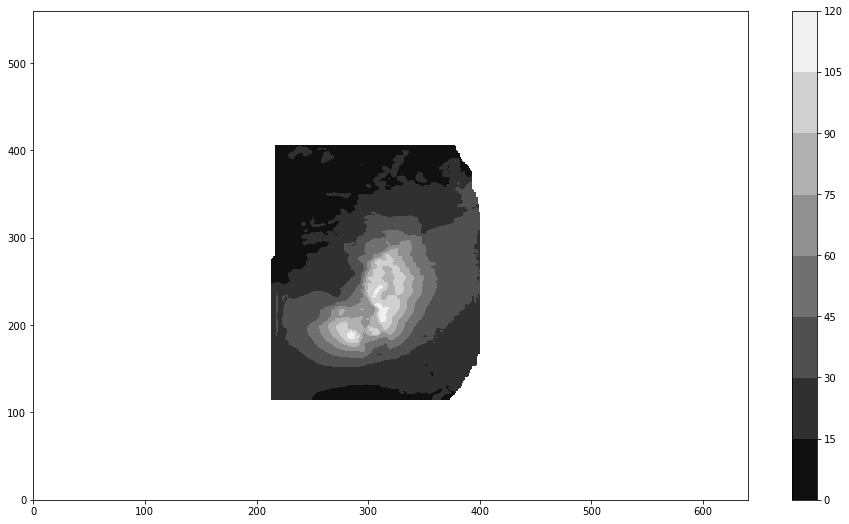

In [97]:
mp.figure(figsize=(16,9))
mp.contourf(hres[::-1,:],cmap="gray")
mp.colorbar()
mp.show()

In [98]:
xmin, xmax, ymin, ymax = longrid.min(), longrid.max(), latgrid.min(), latgrid.max()
ny, nx = longrid.shape
dx, dy = (xmax - xmin) / (nx - 1), (ymax - ymin) / (ny - 1)
xmin, xmax, ymin, ymax, nx, ny, dx, dy

(-100.0, -60.0, 15.0, 50.0, 641, 561, 0.0625, 0.0625)

In [99]:
from osgeo import gdal, osr


In [100]:
ny, nx, hres.T.shape

(561, 641, (641, 561))

In [101]:
geotransform = (xmin, dx, 0, ymax, 0, -dy)
driver = gdal.GetDriverByName('GTiff')
dst_ds = driver.Create(r"Y:\Live CAT Events\2022\Ian 2022\CFAN\GIS\hres_20_2022092900_ECMWF-CFAN.tif", nx, ny, 1, gdal.GDT_Float32)
dst_ds.SetGeoTransform(geotransform)    # specify coords
srs = osr.SpatialReference()            # establish encoding
srs.ImportFromEPSG(4326)                # WGS84 lat/long
dst_ds.SetProjection(srs.ExportToWkt()) # export coords to file
dst_ds.GetRasterBand(1).WriteArray(np.ceil(hres))   # write r-band to the raster
# dst_ds.GetRasterBand(2).WriteArray(g)   # write g-band to the raster
# dst_ds.GetRasterBand(3).WriteArray(b)   # write b-band to the raster
dst_ds.FlushCache()                     # write to disk
dst_ds = None                           # save, close

## asgofiaewjgi

In [102]:
from glob import glob

In [103]:
hres_fnames = glob(r"Y:\Live CAT Events\2022\Ian 2022\CFAN/hres_*.csv")
hres_fnames

['Y:\\Live CAT Events\\2022\\Ian 2022\\CFAN\\hres_20_2022092718_ECMWF-CFAN.csv',
 'Y:\\Live CAT Events\\2022\\Ian 2022\\CFAN\\hres_20_2022092800_ECMWF-CFAN.csv',
 'Y:\\Live CAT Events\\2022\\Ian 2022\\CFAN\\hres_20_2022092806_ECMWF-CFAN.csv',
 'Y:\\Live CAT Events\\2022\\Ian 2022\\CFAN\\hres_20_2022092812_ECMWF-CFAN.csv',
 'Y:\\Live CAT Events\\2022\\Ian 2022\\CFAN\\hres_20_2022092818_ECMWF-CFAN.csv',
 'Y:\\Live CAT Events\\2022\\Ian 2022\\CFAN\\hres_20_2022092900_ECMWF-CFAN.csv']

In [105]:
hres_data = np.array([np.loadtxt(fname,delimiter=",") for fname in hres_fnames])
hres_data.shape

(6, 561, 641)

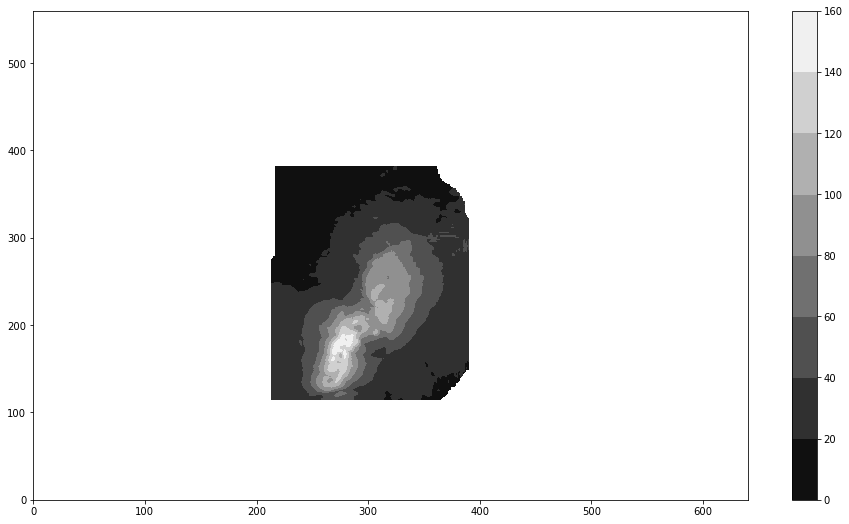

In [110]:
mp.figure(figsize=(16,9))
mp.contourf(hres_data[:,::-1].max(axis=0),cmap="gray")
mp.colorbar()
mp.show()

In [113]:
geotransform = (xmin, dx, 0, ymax, 0, -dy)
driver = gdal.GetDriverByName('GTiff')
dst_ds = driver.Create(r"Y:\Live CAT Events\2022\Ian 2022\CFAN\GIS\hres_20_combined_ECMWF-CFAN_stepped.tif", nx, ny, 1, gdal.GDT_Float32)
dst_ds.SetGeoTransform(geotransform)    # specify coords
srs = osr.SpatialReference()            # establish encoding
srs.ImportFromEPSG(4326)                # WGS84 lat/long
dst_ds.SetProjection(srs.ExportToWkt()) # export coords to file
dst_ds.GetRasterBand(1).WriteArray(np.ceil(hres_data.max(axis=0)/5)*5)   # write r-band to the raster
# dst_ds.GetRasterBand(2).WriteArray(g)   # write g-band to the raster
# dst_ds.GetRasterBand(3).WriteArray(b)   # write b-band to the raster
dst_ds.FlushCache()                     # write to disk
dst_ds = None                           # save, close